# Project_06_Sales Forecasting Across Multiple Retail Stores

### Load the important libraries

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import logging
# Libraries imported for data analysis,visualization and modeling

### Logging

In [2]:
logging.basicConfig(filename="project.log",level=logging.INFO)
logger=logging.getLogger()
logger.info("project started")
# Logging is implemented using python's logging library to track project execution steps such as data loading,preprocessing,and model training

### Load and merge data

In [3]:
# Load the datasets
trainDf=pd.read_csv(r"C:\Users\ajayk\OneDrive\Desktop\Digicrome_E-Learning\Nexthikes Internship Project Training\Project_06\train.csv")
testDf=pd.read_csv(r"C:\Users\ajayk\OneDrive\Desktop\Digicrome_E-Learning\Nexthikes Internship Project Training\Project_06\test.csv")
storeDf=pd.read_csv(r"C:\Users\ajayk\OneDrive\Desktop\Digicrome_E-Learning\Nexthikes Internship Project Training\Project_06\store.csv")

# Merge datasets
df=pd.merge(trainDf,storeDf,on="Store",how="left")
# The training dataset was merged with store dataset using the "Store" column to include store-level information

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\3365253795.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  trainDf=pd.read_csv(r"C:\Users\ajayk\OneDrive\Desktop\Digicrome_E-Learning\Nexthikes Internship Project Training\Project_06\train.csv")


In [4]:
# Complete rows and columns
pd.set_option("display.max_rows",None)
pd.set_option("display.max_columns",None)
pd.set_option("display.max_colwidth",None)
# pd.set_option is the method by which we can see the complete rows as well as columns

### Data understanding

**Dimensions**

In [5]:
df.shape
# It will display the total number of rows and columns.We've 1017209 rows and 18 columns

(1017209, 18)

In [6]:
print("Total number of rows:",df.shape[0])
print("Total number of columns:",df.shape[1])

Total number of rows: 1017209
Total number of columns: 18


### Information

In [7]:
# Column types and non-null counts
df.info()
# It will give the complete info of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

**Describe**

In [8]:
# Statistical summary
df.describe()
# It will give us the statistical info of the dataframe

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000


**Head**

In [9]:
df.head()
# By default it displays first five rows and it will always display from the starting only

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


**Tail**

In [10]:
df.tail()
# By default it displays last five rows and it will always display from the ending only

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN
1017208,1115,2,2013-01-01,0,0,0,0,a,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"


**Sample**

In [11]:
df.sample()
# It displays random rows.By default it display one random row

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
834953,604,4,2013-06-13,5984,495,1,0,0,0,d,a,10950.0,3.0,2014.0,0,NaN,NaN,NaN


**Columns**

In [12]:
df.columns
# It will display the columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

### Check duplicates and drop duplicates

In [13]:
# To find the duplicate rows->duplicated()
print("Total Number of Duplicate rows:",df.duplicated().sum())
# There are no duplicate rows.So we don't need to identify and drop duplicates

Total Number of Duplicate rows: 0


### Handle missing values

In [14]:
df.isna().sum() # It displays column wise count of missing values
# There are 2642 missing values in "CompetitionDistance"
# 323348 missing values in "CompetitionOpenSinceMonth"
# 323348 missing values in "CompetitionOpenSinceYear"
# 508031 missing values in "Promo2SinceWeek"
# 508031 missing values in "Promo2SinceYear"
# 508031 missing values in "PromoInterval"

# No columns were dropped as missing values carried meaningfull business information.Instead,appropriate imputaion techniques were applied

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

### Check data type

In [15]:
# Check the data type
print(df["CompetitionDistance"].dtypes)
print(df["CompetitionOpenSinceMonth"].dtypes)
print(df["CompetitionOpenSinceYear"].dtypes)
print(df["Promo2SinceWeek"].dtypes)
print(df["Promo2SinceYear"].dtypes)
print(df["PromoInterval"].dtypes)

float64
float64
float64
float64
float64
object


<Axes: xlabel='CompetitionDistance', ylabel='Count'>

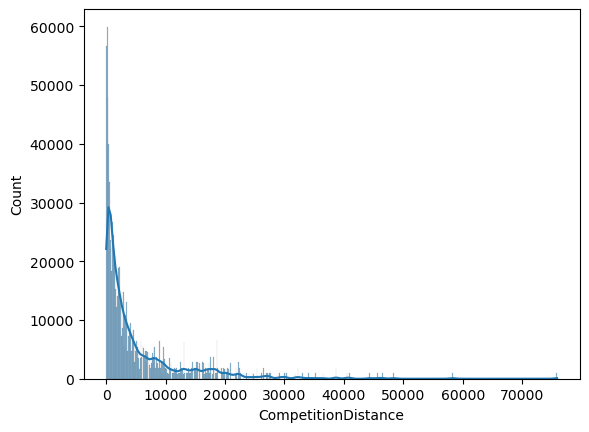

In [16]:
sns.histplot(df["CompetitionDistance"],kde=True)

- CompetitionDistance

In [17]:
# Filled missing values using median to reduce effect of outliers
tempMedian=df["CompetitionDistance"].median()
df["CompetitionDistance"].fillna(tempMedian,inplace=True)
# Although missing values were less than 30%,median was used instead of mean due to skewness and presence of outliers in the data

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\347951158.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["CompetitionDistance"].fillna(tempMedian,inplace=True)


- CompetitionOpenSinceMonth

In [18]:
tempValue=0
df["CompetitionOpenSinceMonth"].fillna(tempValue,inplace=True)
# Filled missing values with 0 indicating no competition data

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\3267151726.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["CompetitionOpenSinceMonth"].fillna(tempValue,inplace=True)


- CompetitionOpenSinceYear

In [19]:
tempValue=0
df["CompetitionOpenSinceYear"].fillna(tempValue,inplace=True)

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\2509012523.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["CompetitionOpenSinceYear"].fillna(tempValue,inplace=True)


- Promo2SinceWeek

In [20]:
tempValue=0
df["Promo2SinceWeek"].fillna(tempValue,inplace=True)

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\2196003472.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Promo2SinceWeek"].fillna(tempValue,inplace=True)


- Promo2SinceYear

In [21]:
tempValue=0
df["Promo2SinceYear"].fillna(tempValue,inplace=True)

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\630025481.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Promo2SinceYear"].fillna(tempValue,inplace=True)


*Although these variables are numeric,missing values represent absence of competition or promotions,*
*hence they were replaced with 0 instead of statistical measures*

- PromoInterval(Categorical)

In [22]:
# Filled missing categorical values with "None"
tempValue="None"
df["PromoInterval"].fillna(tempValue,inplace=True)
# "PromoInterval" missing values were filled with ‘None’ to indicate absence of promotional activity

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\2637631863.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["PromoInterval"].fillna(tempValue,inplace=True)


In [23]:
# Check the missing values
df.isna().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

*We stored imputation values in variables and then applied fillna to improve code readability and maintainability*

**Check unique values**

In [24]:
for col in df.columns:
    print(col,df[col].nunique())
# Unique values counts were used to distinguish between categorical and continuous variables

Store 1115
DayOfWeek 7
Date 942
Sales 21734
Customers 4086
Open 2
Promo 2
StateHoliday 5
SchoolHoliday 2
StoreType 4
Assortment 3
CompetitionDistance 654
CompetitionOpenSinceMonth 13
CompetitionOpenSinceYear 24
Promo2 2
Promo2SinceWeek 25
Promo2SinceYear 8
PromoInterval 4


### Cont numeric vs Categorical columns

**Identify column types**

In [25]:
numColumns=df.select_dtypes(include=["int64","float64"]).columns.tolist()
catColumns=df.select_dtypes(include=["object"]).columns.tolist()

# Add numeric columns that behave like categories
catColumns+=["Promo","SchoolHoliday","DayOfWeek"]
# Categorical variables were identified using data types and domain understanding,including variables like "Promo","SchoolHoliday","DayOfWeek"

**Print counts and column names**

In [26]:
# Print counts
print("Number of Numeric Columns:",len(numColumns))
print("Number of Categorical Columns:",len(catColumns))

# Print columm names
print("\nNumeric Column Names:\n",list(numColumns))
print("\nCategorical Column Names:\n",list(catColumns))

Number of Numeric Columns: 13
Number of Categorical Columns: 8

Numeric Column Names:
 ['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear']

Categorical Column Names:
 ['Date', 'StateHoliday', 'StoreType', 'Assortment', 'PromoInterval', 'Promo', 'SchoolHoliday', 'DayOfWeek']


### Identify discrete vs Continuous variables

In [27]:
contColumns=[col for col in numColumns if df[col].nunique()>25] # >25 assumed continuous(If values are small like 2,7,10)
discColumns=[col for col in numColumns if df[col].nunique()<=25] #<=25 assumed discrete(If values are large like 100,500,1000)
print("Continuous Columns:",contColumns)
print("Discrete Columns:",discColumns)
# Columns with fewer unique values were treated as discrete,while those with many unique values were treated as continuous

Continuous Columns: ['Store', 'Sales', 'Customers', 'CompetitionDistance']
Discrete Columns: ['DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear']


*Numerical variables were classified into continuous and discrete based on the number of unique values present in each feature*

### Feature engineering

In [28]:
# Convert date column into datetime format
df["Date"]=pd.to_datetime(df["Date"])

# Extract basic time features for analysis
df["Year"]=df["Date"].dt.year
df["Month"]=df["Date"].dt.month
df["MonthName"]=df["Date"].dt.month_name()
df["Day"]=df["Date"].dt.day
df["DayName"]=df["Date"].dt.day_name()

# The date column was converted into datetime format and basic features such as year,month,and day were extracted to enable meaningful analysis

*Basic date features were extracted before EDA to facilitate analysis.*

### Create clean EDA data

In [29]:
# Create a copy for EDA
df_eda=df.copy()

# Remove date column
df_eda.drop(["Date"],axis=1,inplace=True)
# "Date" column was removed before EDA as it has high cardianality and does not provide meaningful insights for categorical 

# Remove PromoInterval only for EDA
if "PromoInterval" in df_eda.columns:
    df_eda.drop("PromoInterval",axis=1,inplace=True)
# PromoInterval was excluded from univariate analysis due to its complex multi-value structure, but retained in the dataset for potential use in modeling

### Define categorical columns

In [30]:
# Automatically detect categorical columns
catColumns=df_eda.select_dtypes(include=["object"]).columns.tolist()
print("Final Categorical Columns:",catColumns)

Final Categorical Columns: ['StateHoliday', 'StoreType', 'Assortment', 'MonthName', 'DayName']


### Univariate analysis for continuous variables

**Histogram with KDE**

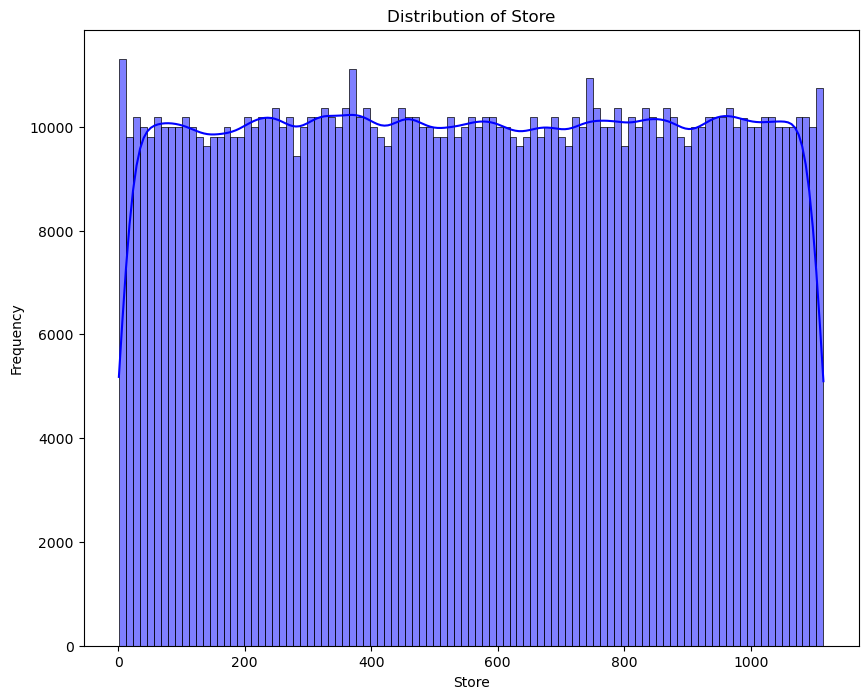

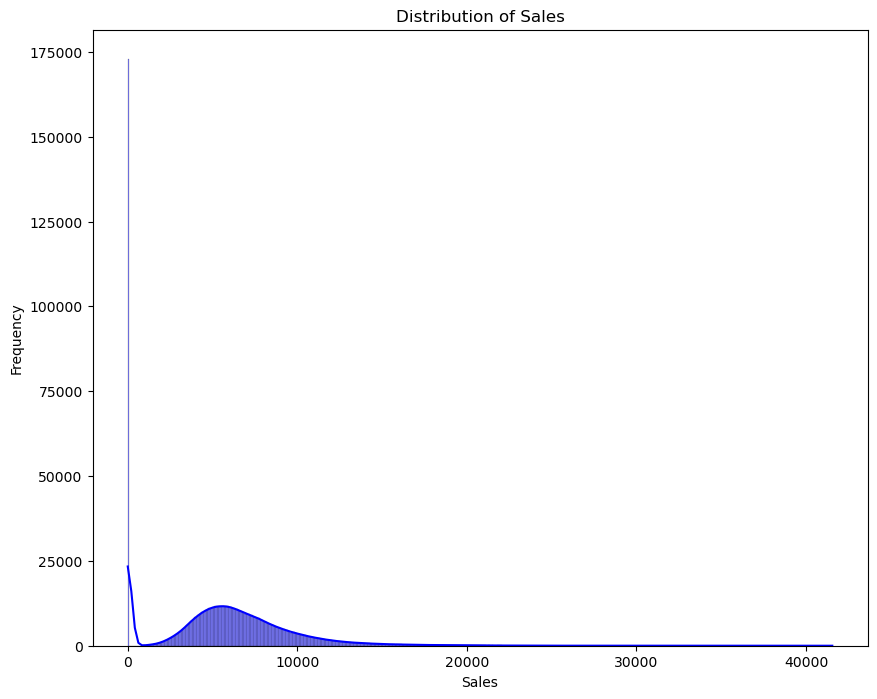

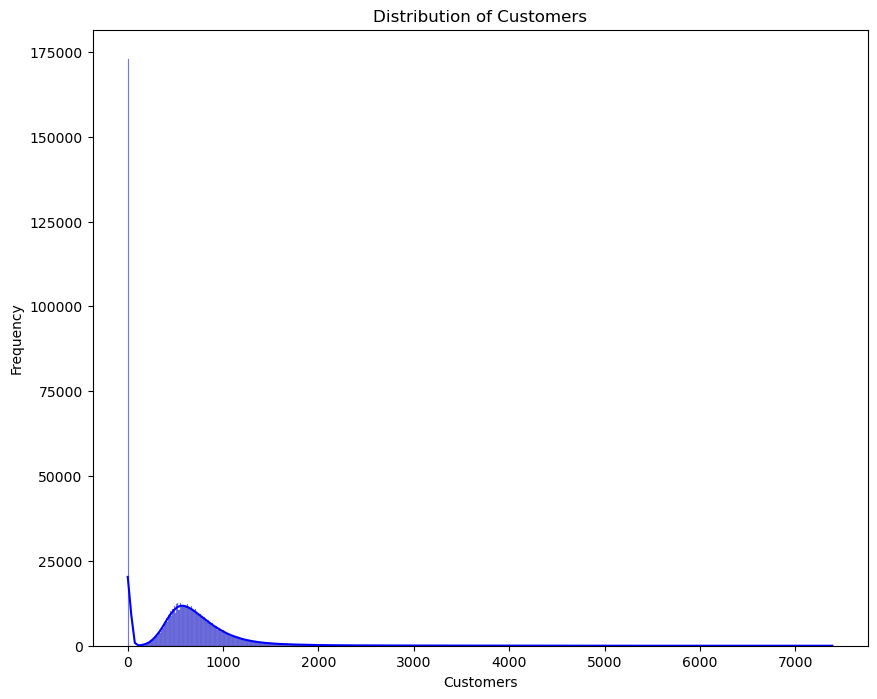

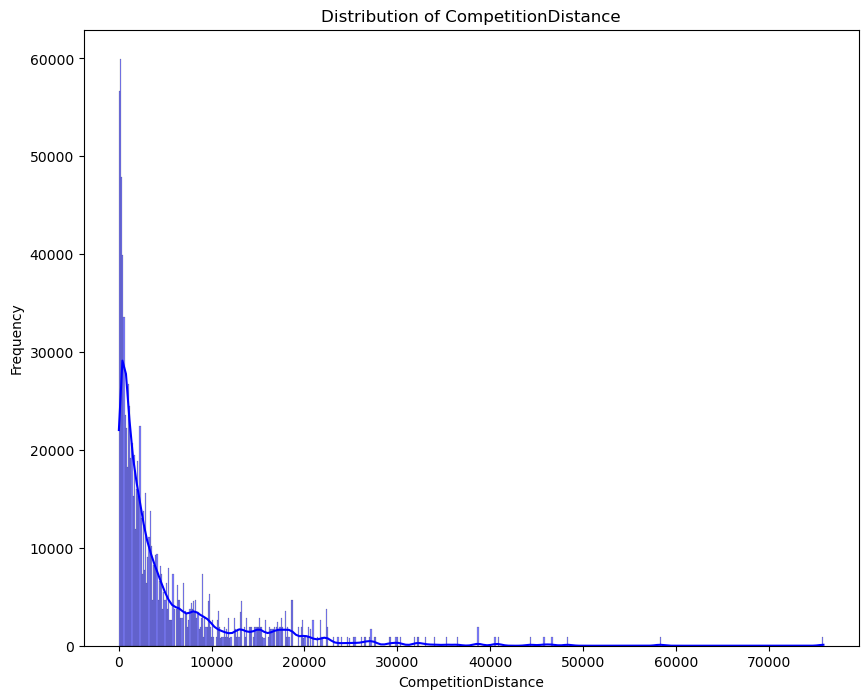

In [31]:
for col in contColumns:
    plt.figure(figsize=(10,8))
    sns.histplot(df[col],kde=True,color="blue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
# This plot shows the distribution of the variables including its spread,skewness,and presence of outliers

**Boxplot**

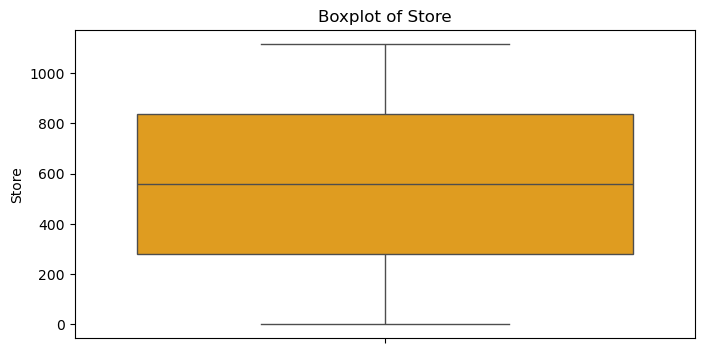

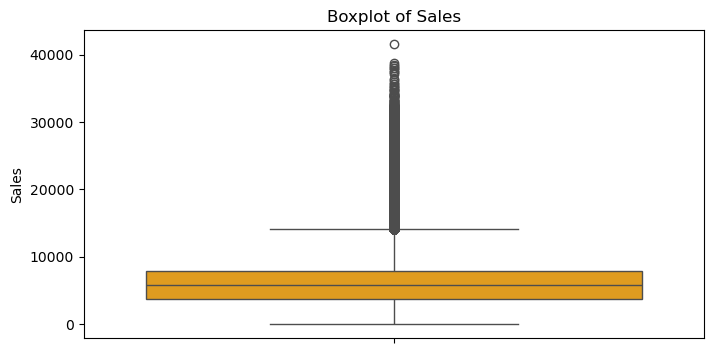

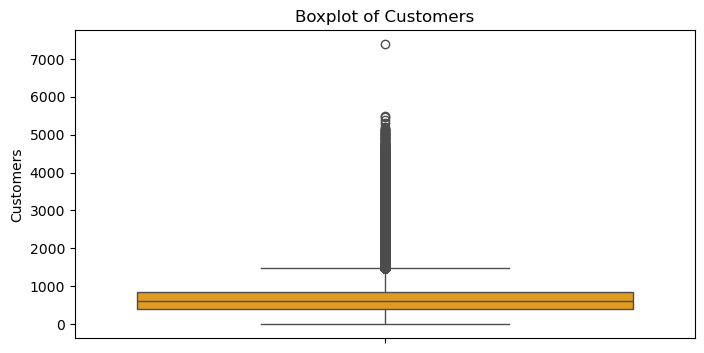

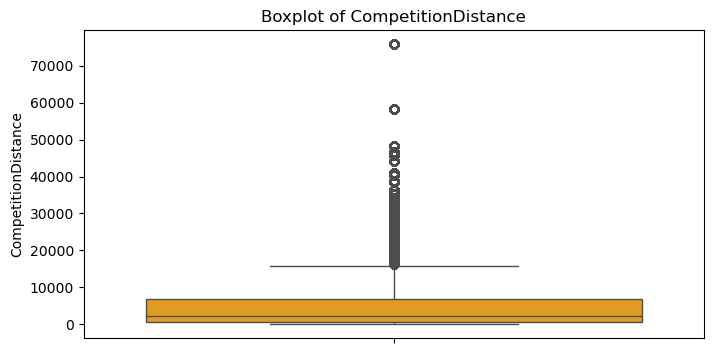

In [32]:
for col in contColumns:
    plt.figure(figsize=(8,4))
    sns.boxplot(y=df[col],color="orange")
    plt.title(f"Boxplot of {col}")
    plt.show()
# Boxplot helps identify outliers and spread of data

*Univariate analysis was performed on continuous variable using histograms and boxplots to understand distribution, skewness, and presence of outliers.*

### Univariate analysis for discrete variables

**Countplot**

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\2391833474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette="viridis")


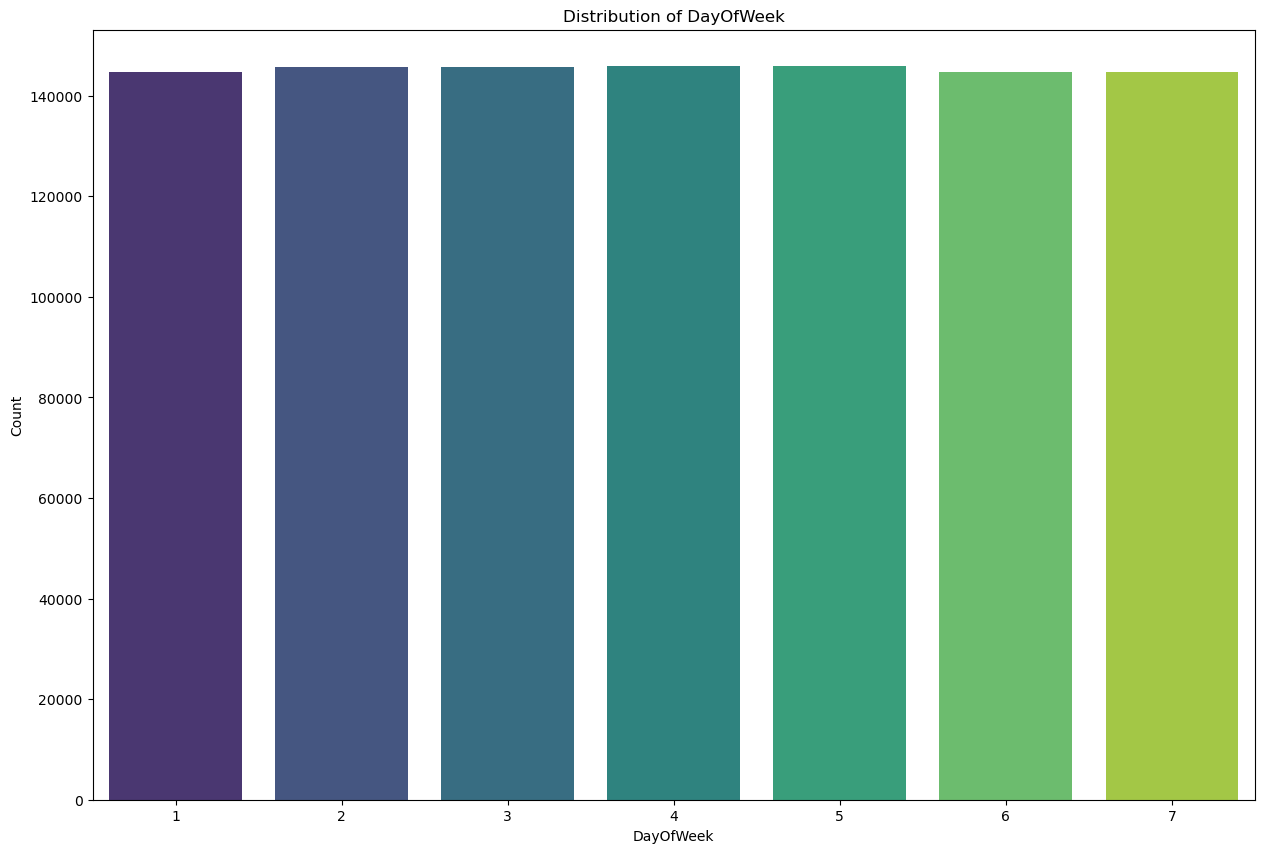

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\2391833474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette="viridis")


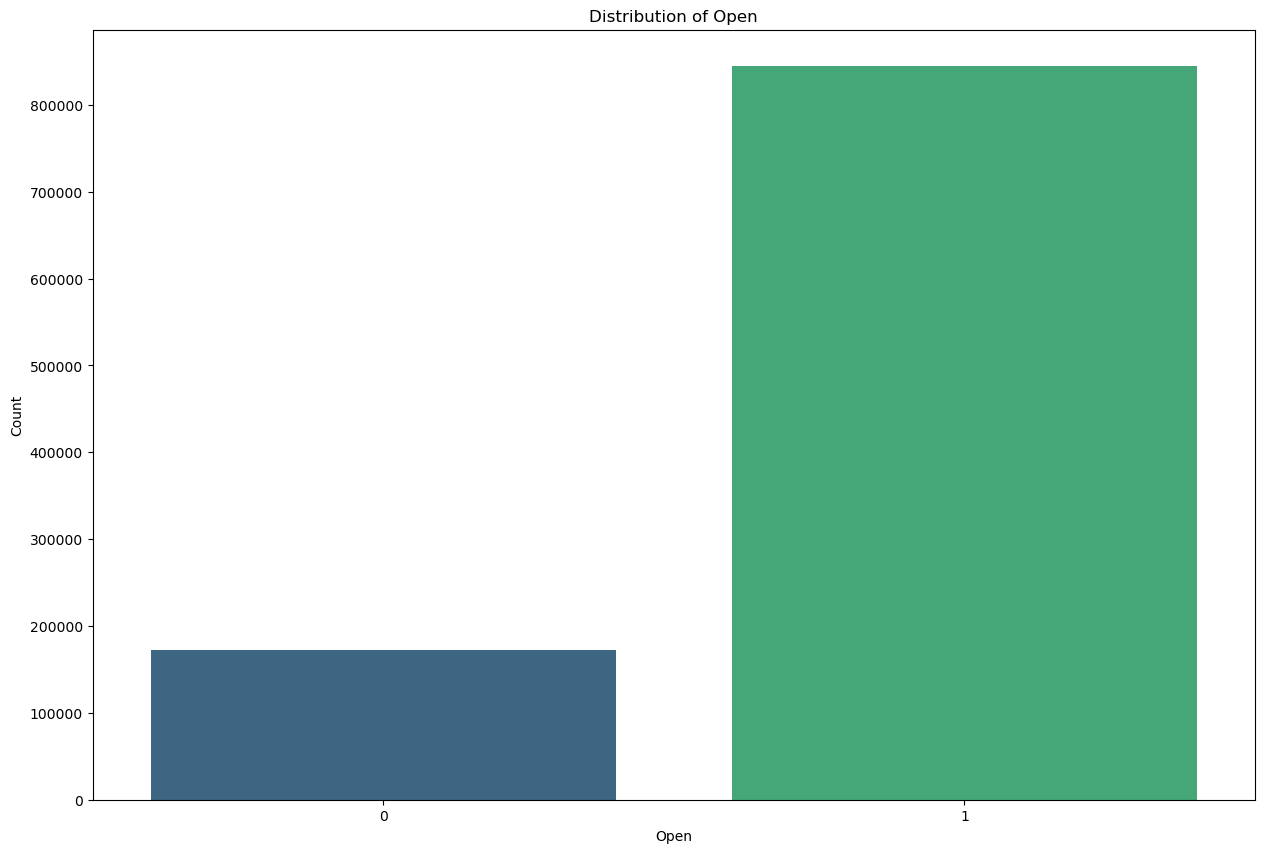

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\2391833474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette="viridis")


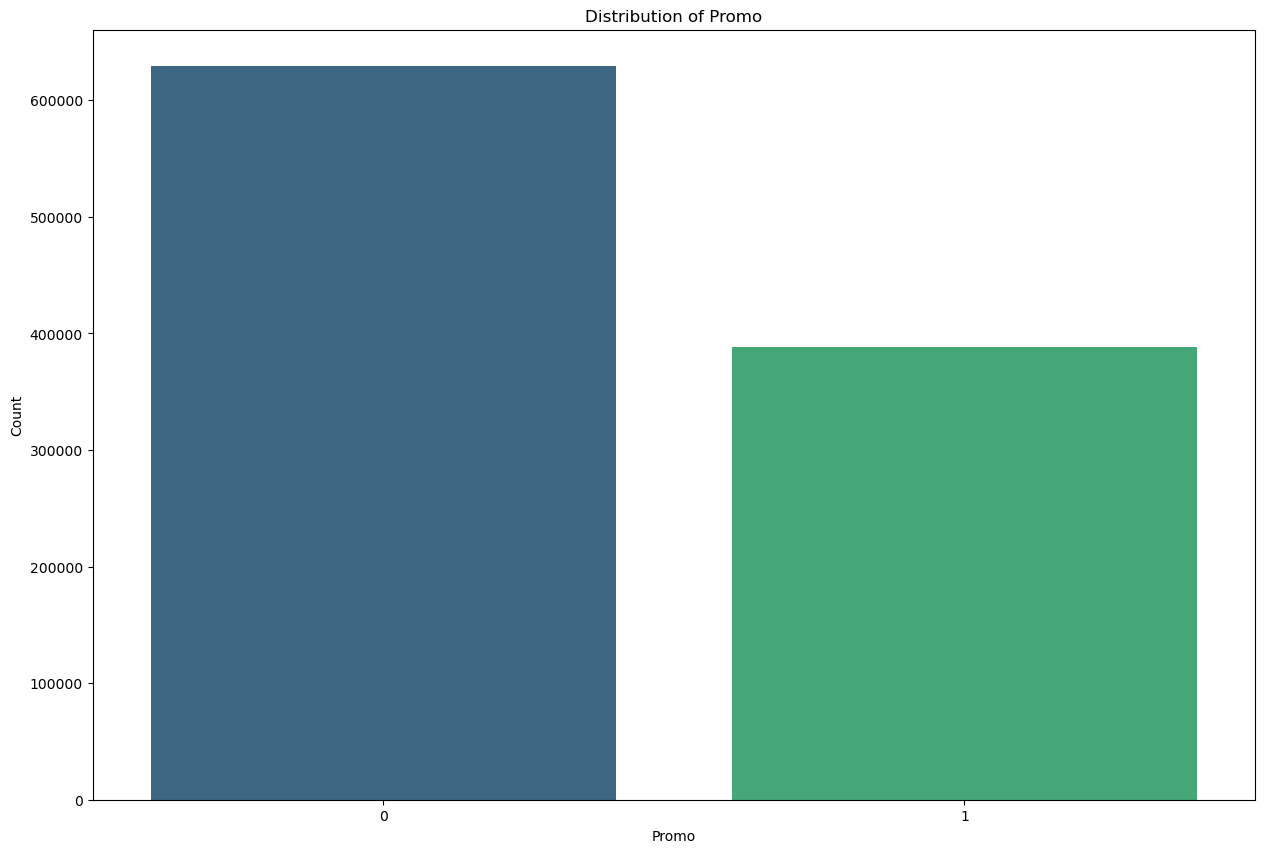

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\2391833474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette="viridis")


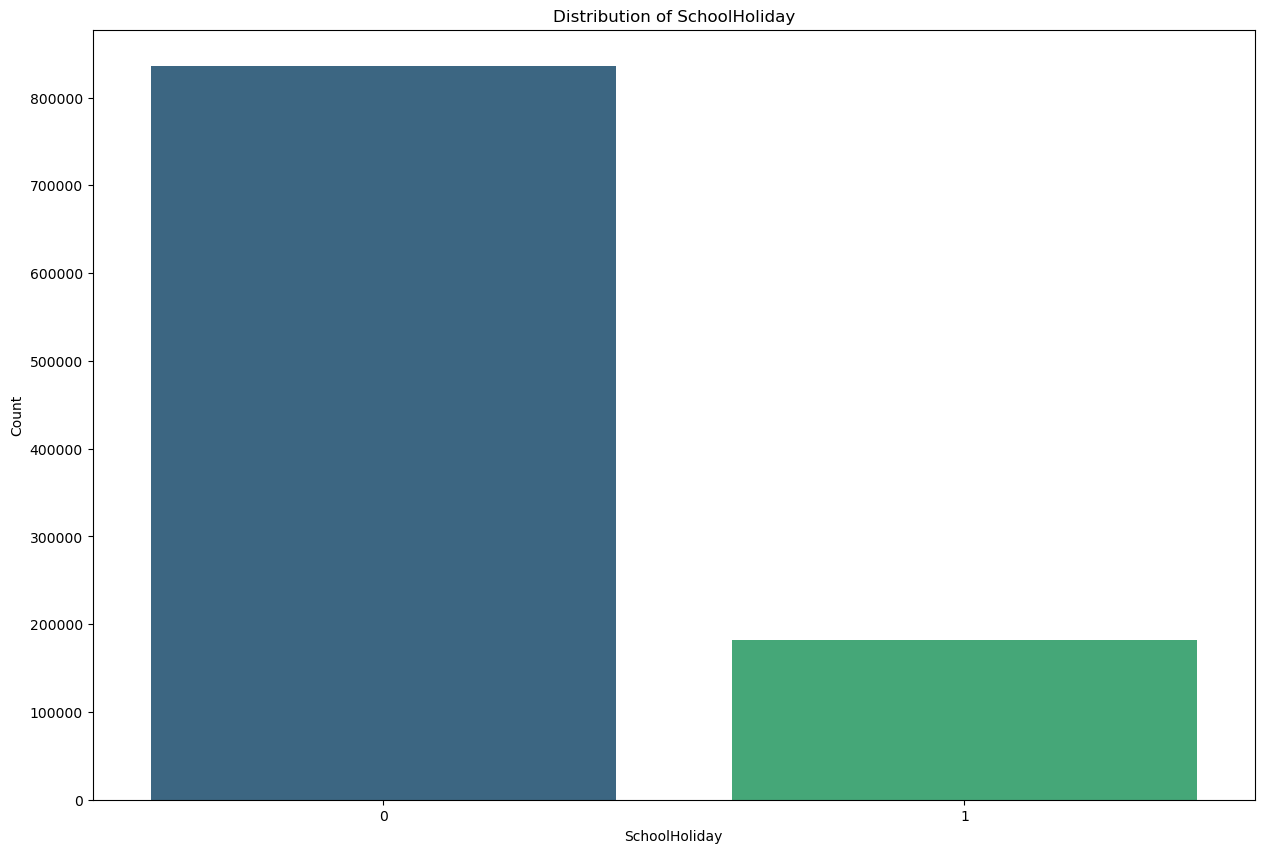

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\2391833474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette="viridis")


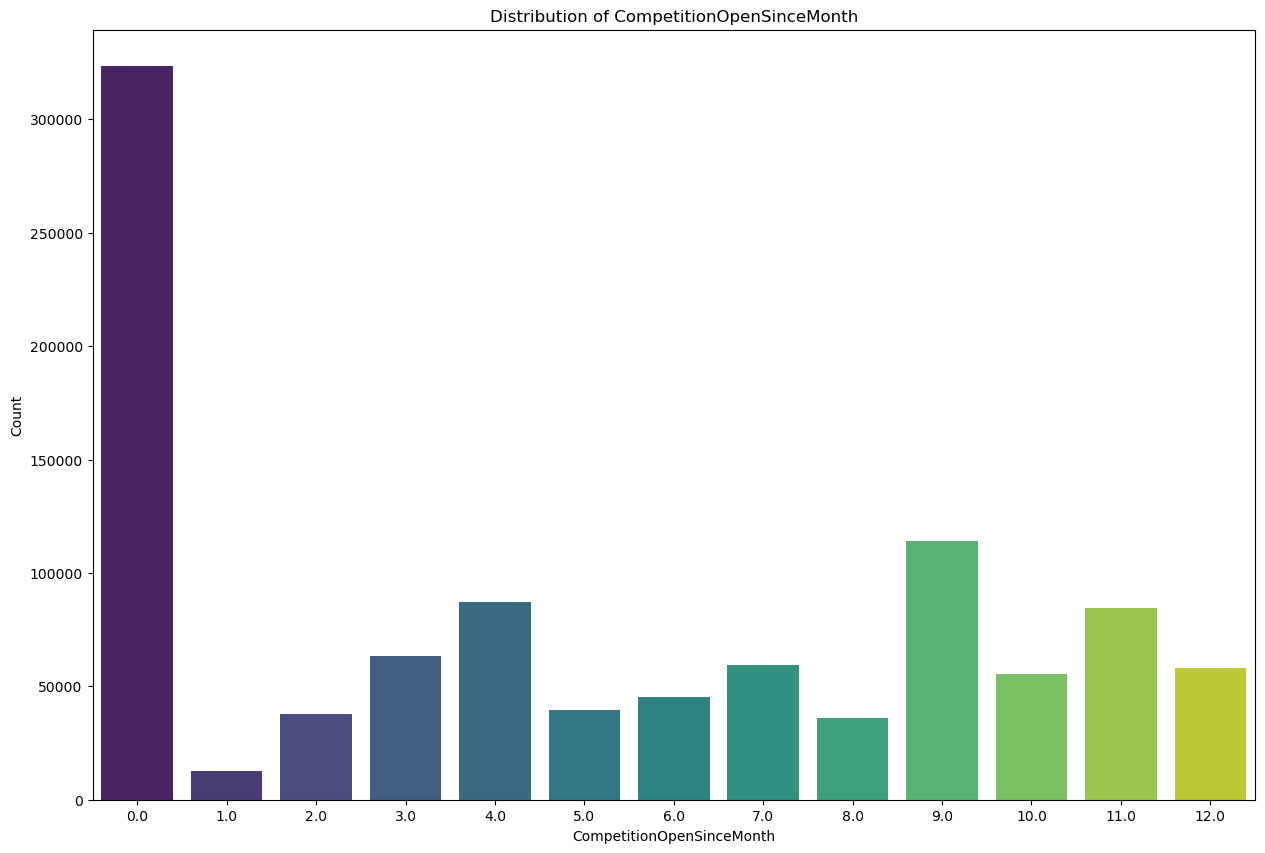

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\2391833474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette="viridis")


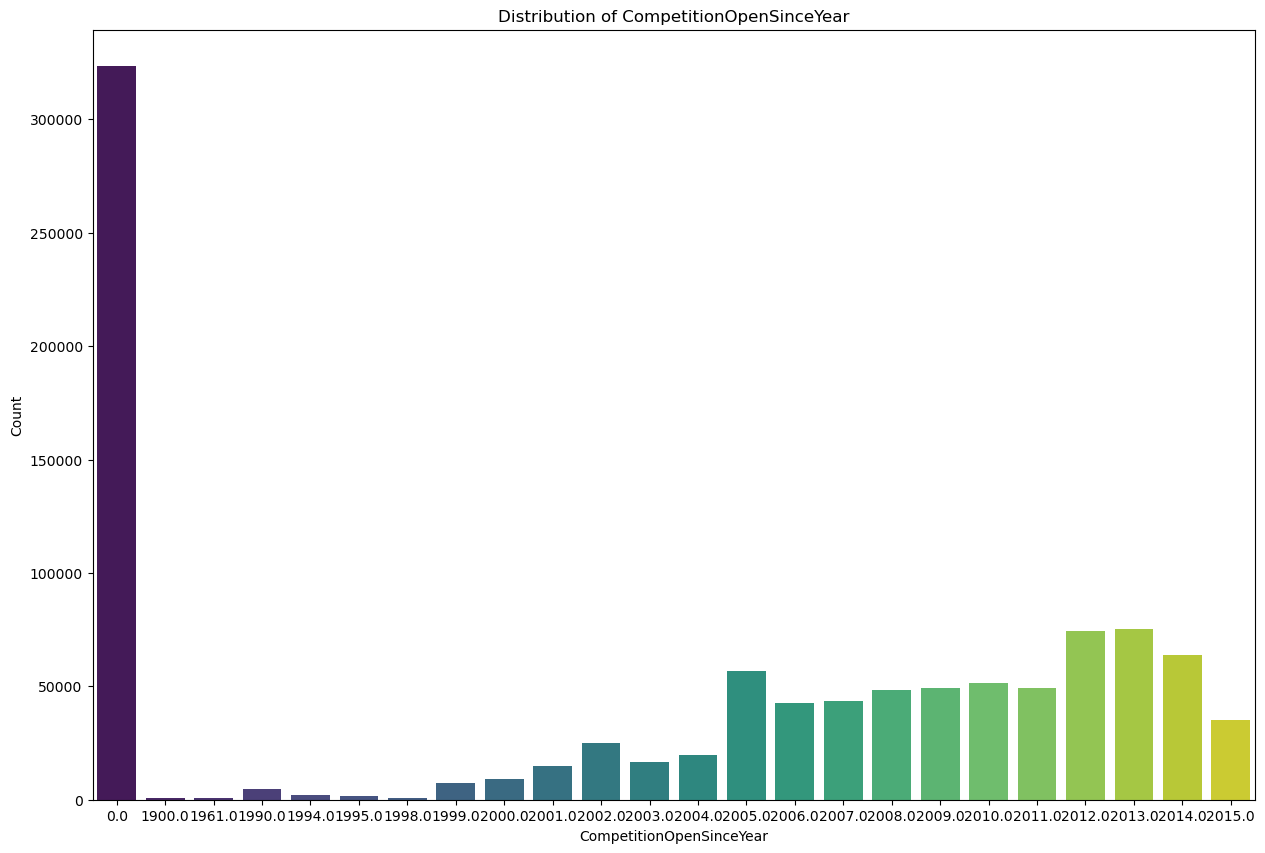

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\2391833474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette="viridis")


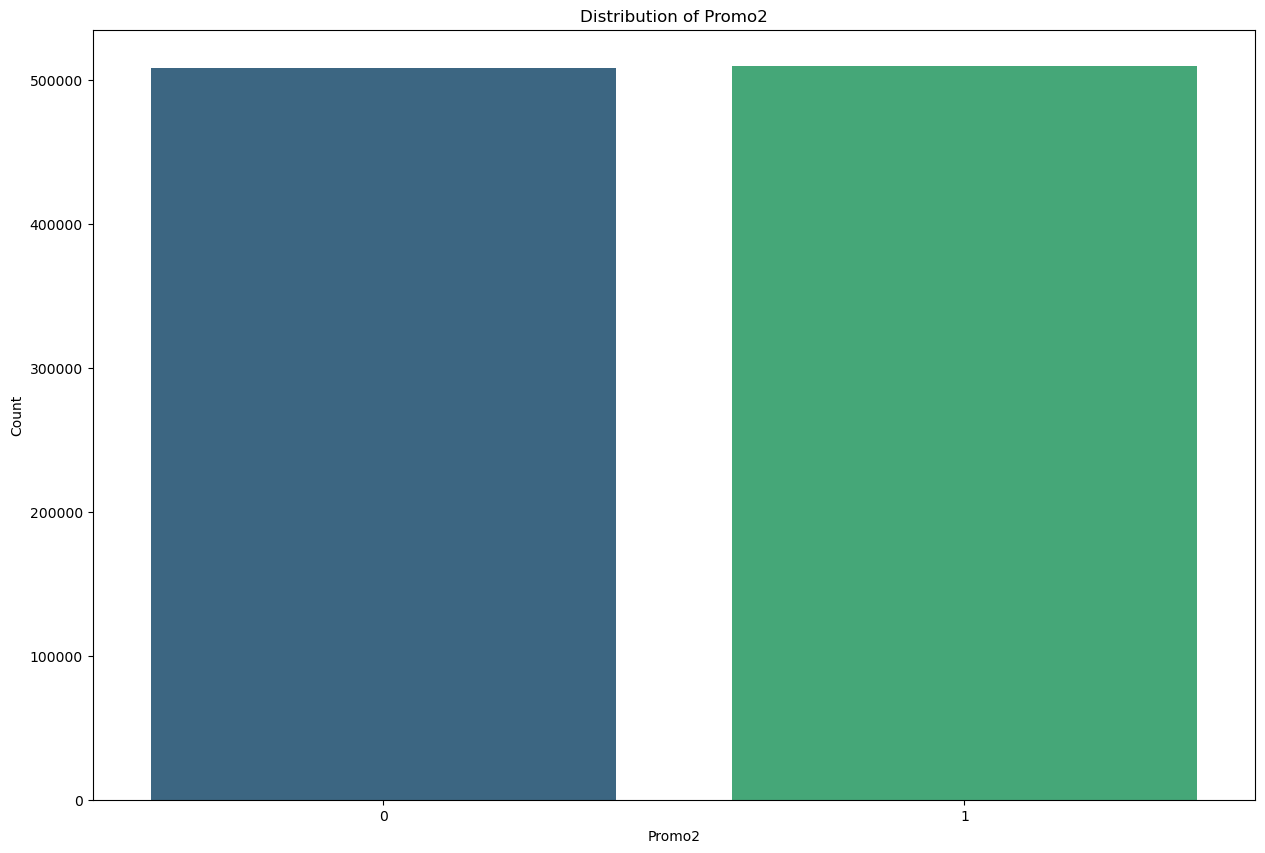

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\2391833474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette="viridis")


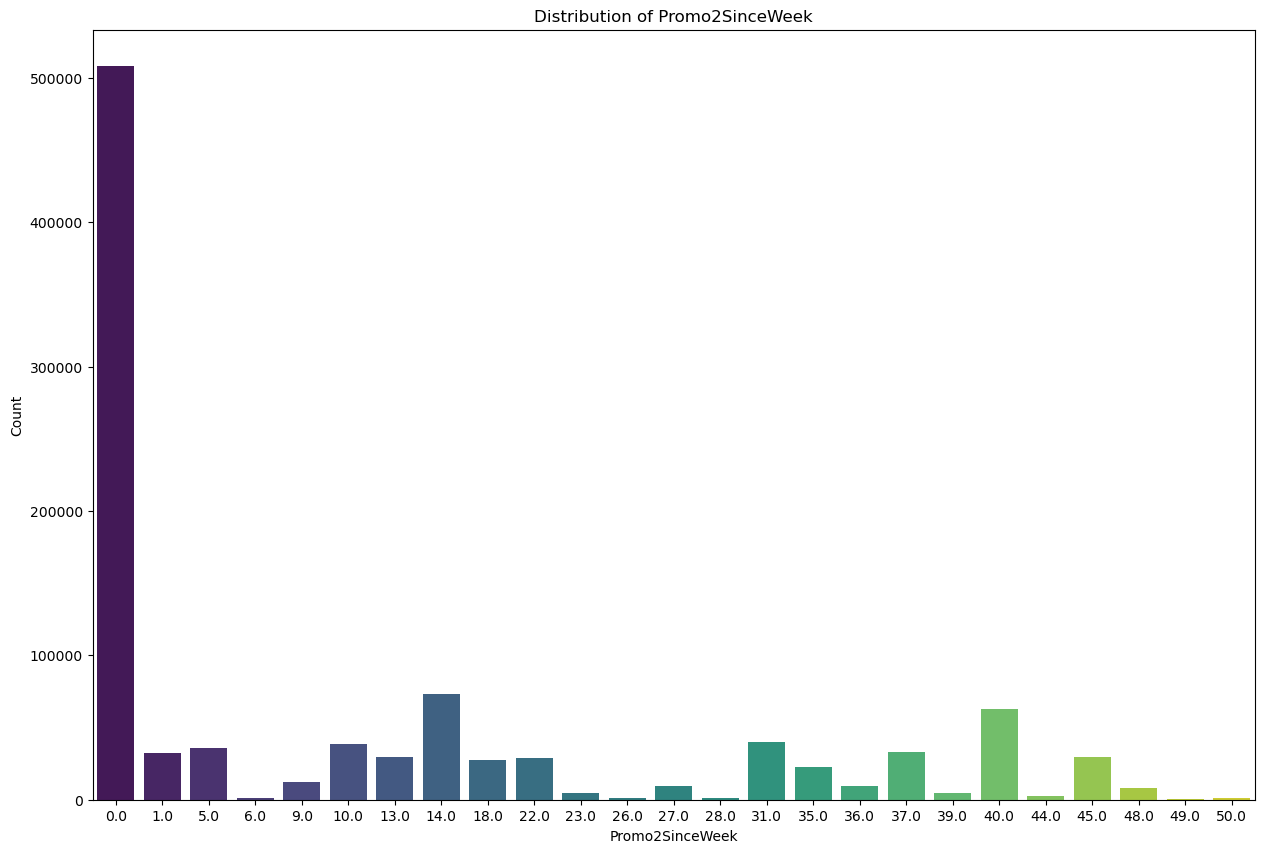

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\2391833474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette="viridis")


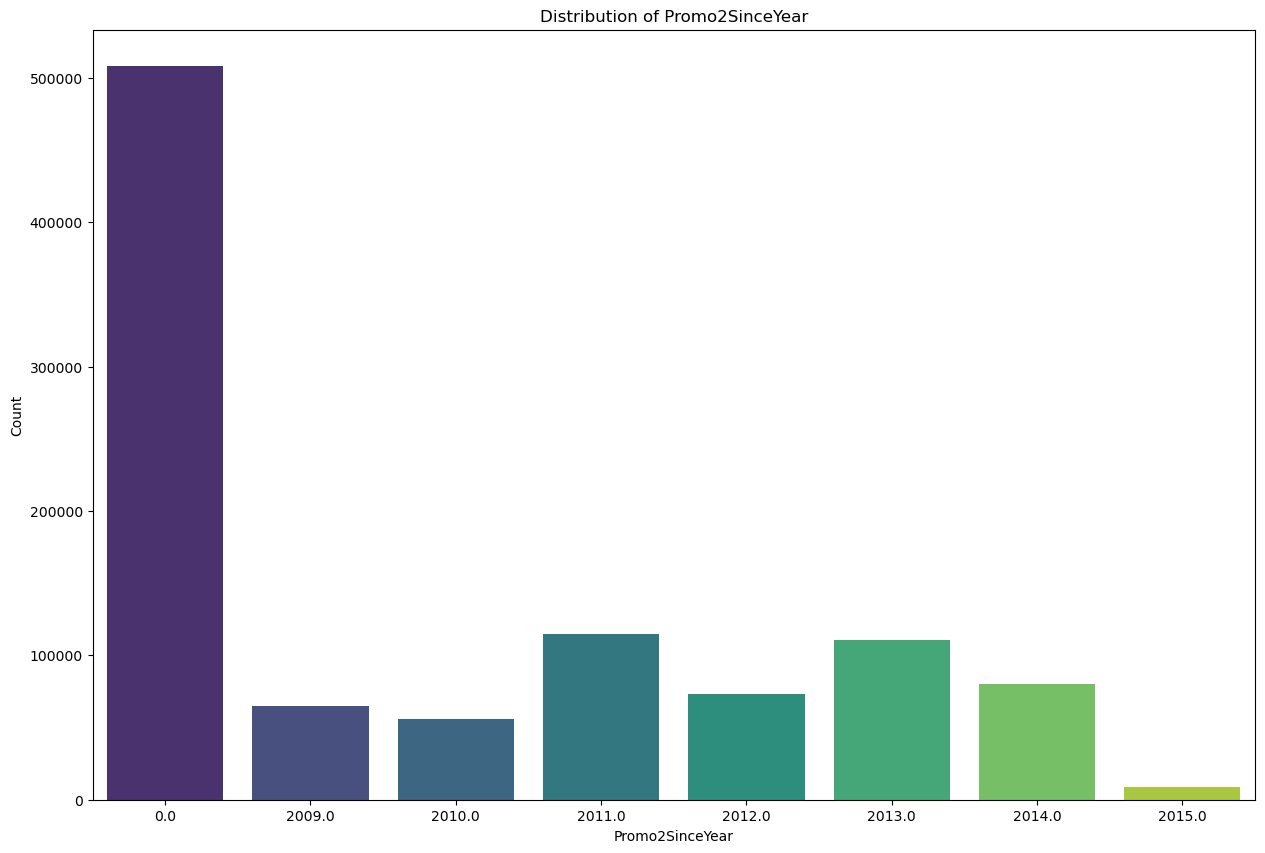

In [33]:
for col in discColumns:
    plt.figure(figsize=(15,10))
    sns.countplot(x=df[col],palette="viridis")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()
# Countplot shows the frequency distribution of discrete values and helps understand how data is distributed across categories

*Univariate analysis for discrete variables was performed using count plots to understand the frequency distribution of each category.*

### Percentage view for discrete variables

In [34]:
for col in discColumns:
    print(f"Percentage Distribution of {col}:\n")
    print(df[col].value_counts(normalize=True)*100)
# Show percentage distribution for better understanding of proportions

Percentage Distribution of DayOfWeek:

DayOfWeek
5    14.337761
4    14.337761
3    14.320066
2    14.319968
1    14.228148
7    14.228148
6    14.228148
Name: proportion, dtype: float64
Percentage Distribution of Open:

Open
1    83.010669
0    16.989331
Name: proportion, dtype: float64
Percentage Distribution of Promo:

Promo
0    61.848548
1    38.151452
Name: proportion, dtype: float64
Percentage Distribution of SchoolHoliday:

SchoolHoliday
0    82.135333
1    17.864667
Name: proportion, dtype: float64
Percentage Distribution of CompetitionOpenSinceMonth:

CompetitionOpenSinceMonth
0.0     31.787764
9.0     11.232107
4.0      8.560286
11.0     8.302620
3.0      6.247290
7.0      5.842850
12.0     5.691652
10.0     5.468099
6.0      4.467518
5.0      3.893792
2.0      3.724505
8.0      3.557381
1.0      1.224134
Name: proportion, dtype: float64
Percentage Distribution of CompetitionOpenSinceYear:

CompetitionOpenSinceYear
0.0       31.787764
2013.0     7.414995
2012.0     7.304202


*Percentage distribution was analyzed to understand the proportion of each category within the variable.*

### Univariate analysis for categorical variables

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\4149568742.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_eda[col],palette="viridis")


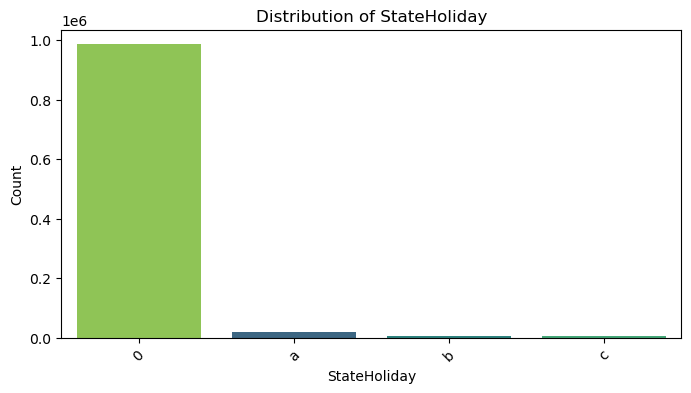

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\4149568742.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_eda[col],palette="viridis")


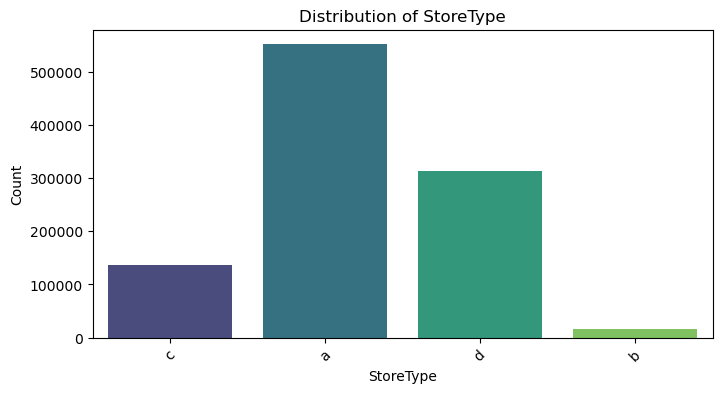

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\4149568742.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_eda[col],palette="viridis")


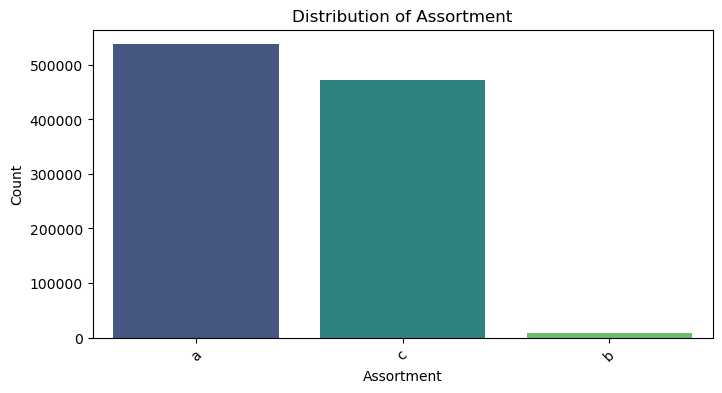

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\4149568742.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_eda[col],palette="viridis")


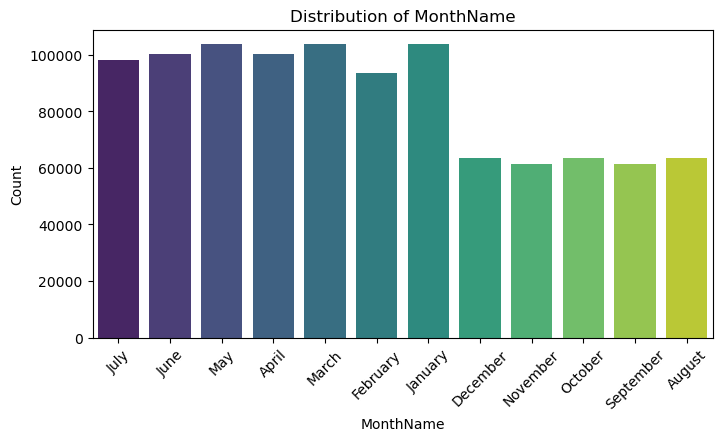

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\4149568742.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_eda[col],palette="viridis")


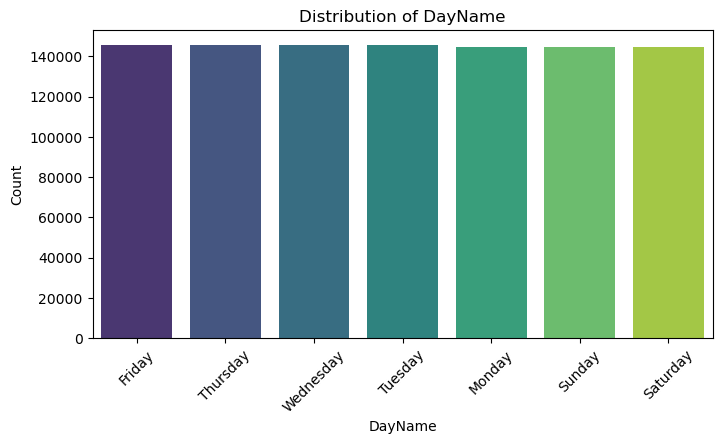

In [35]:
for col in catColumns:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df_eda[col],palette="viridis")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45) # Important for readability
    plt.show()
# Countplot shows the frequency of each category,helping understanding the distribution and dominance of categories

### Percentage view for categorical variables

In [36]:
for col in catColumns:
    print(f"\nPercentage Distribution of {col}:\n")
    percent=(df_eda[col].value_counts(normalize=True)*100).round(2)
    print(percent)
# Percentage distribution helps understand dominance of categories


Percentage Distribution of StateHoliday:

StateHoliday
0    84.06
0    12.89
a     1.99
b     0.66
c     0.40
Name: proportion, dtype: float64

Percentage Distribution of StoreType:

StoreType
a    54.23
d    30.76
c    13.45
b     1.56
Name: proportion, dtype: float64

Percentage Distribution of Assortment:

Assortment
a    52.84
c    46.35
b     0.82
Name: proportion, dtype: float64

Percentage Distribution of MonthName:

MonthName
May          10.19
March        10.19
January      10.19
June          9.87
April         9.87
July          9.65
February      9.21
December      6.25
October       6.25
August        6.25
November      6.05
September     6.05
Name: proportion, dtype: float64

Percentage Distribution of DayName:

DayName
Friday       14.34
Thursday     14.34
Wednesday    14.32
Tuesday      14.32
Monday       14.23
Sunday       14.23
Saturday     14.23
Name: proportion, dtype: float64


*Categorical variables were analyzed using count plots and percentage distributions to understand the frequency and dominance of different categories.*

### Bivariate analysis for continuous vs Sales

**Scatterplots(Numeric vs Sales)**

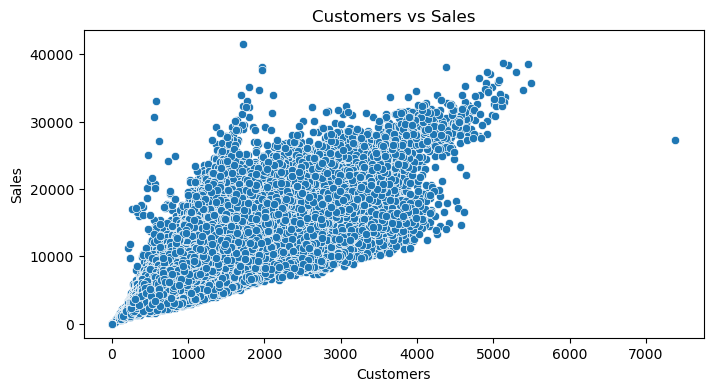

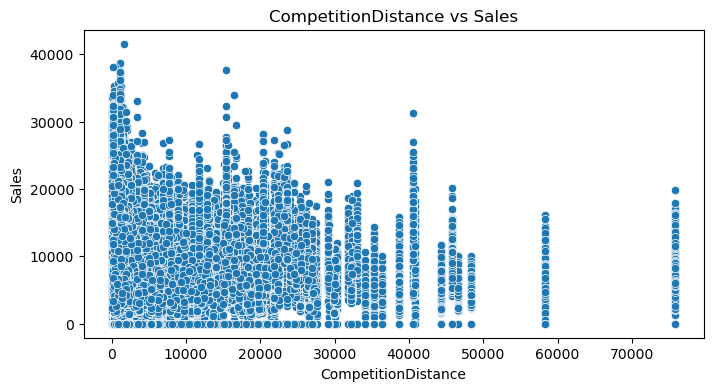

In [37]:
contColumns=["Customers","CompetitionDistance"]
for col in contColumns:
    plt.figure(figsize=(8,4))
    sns.scatterplot(x=df_eda[col],y=df_eda["Sales"])
    plt.title(f"{col} vs Sales")
    plt.xlabel(col)
    plt.ylabel("Sales")
    plt.show()
# Scatterplot used to analyze relationship between continuous variable and Sales

*Scatterplots were used to analyze the relationship between continuous variables and Sales.*

**With regression line**

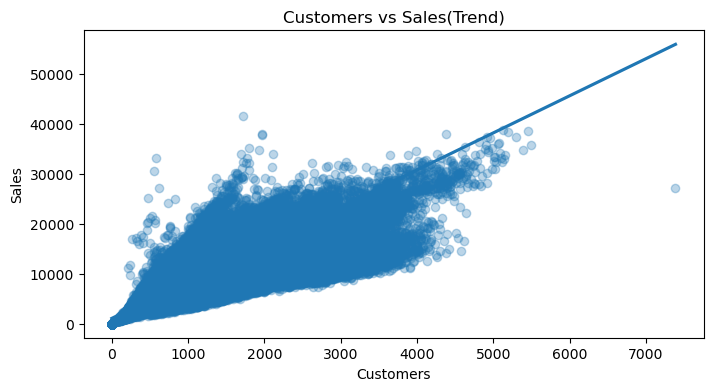

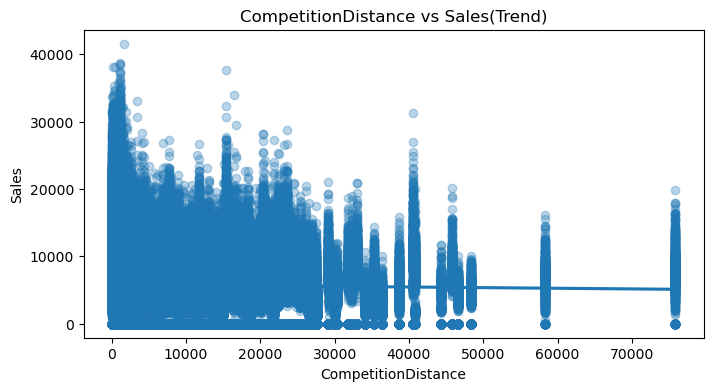

In [38]:
for col in contColumns:
    plt.figure(figsize=(8,4))
    sns.regplot(x=df_eda[col],y=df_eda["Sales"],scatter_kws={"alpha":0.3})
    plt.title(f"{col} vs Sales(Trend)")
    plt.xlabel(col)
    plt.ylabel("Sales")
    plt.show()
# Regression plots were used to analyze the relationship between continuous variable and Sales
# A strong positive trend was observed between Customers and Sales,while CompetitionDistance showed weak influence

*scatter_kws-> Keyword arguments(kws) were used to customize plot appearance for better visualization.*

*"alpha":0.3-> Transparency(alpha) was adjusted in scatterplots to improve visualization and handle overlapping data points.*

### Bivariate analysis for categorical vs Sales

**Boxplots(Categorical vs Sales)**

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\1029565144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_eda[col],y=df_eda["Sales"],palette="Set2")


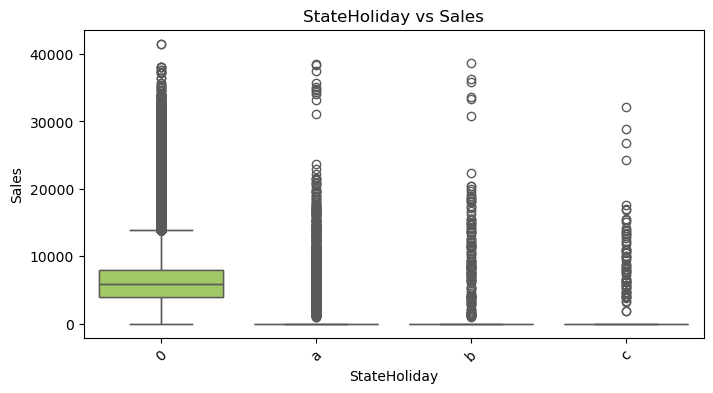

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\1029565144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_eda[col],y=df_eda["Sales"],palette="Set2")


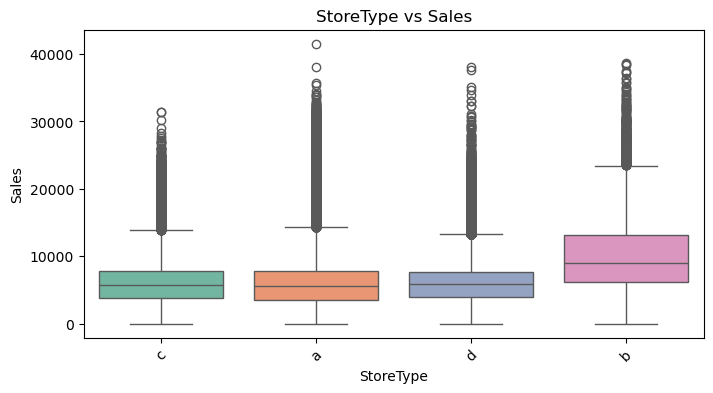

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\1029565144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_eda[col],y=df_eda["Sales"],palette="Set2")


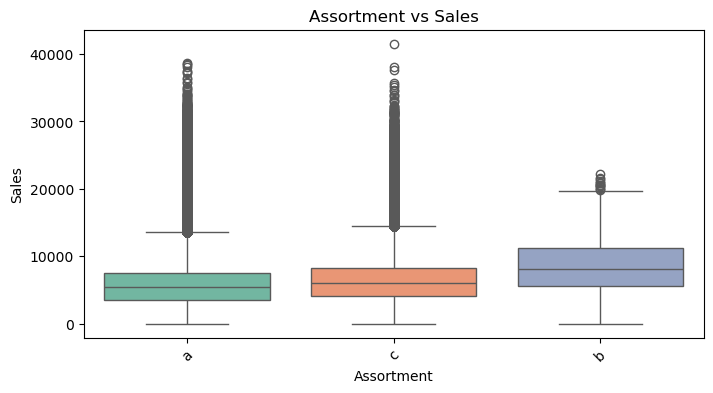

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\1029565144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_eda[col],y=df_eda["Sales"],palette="Set2")


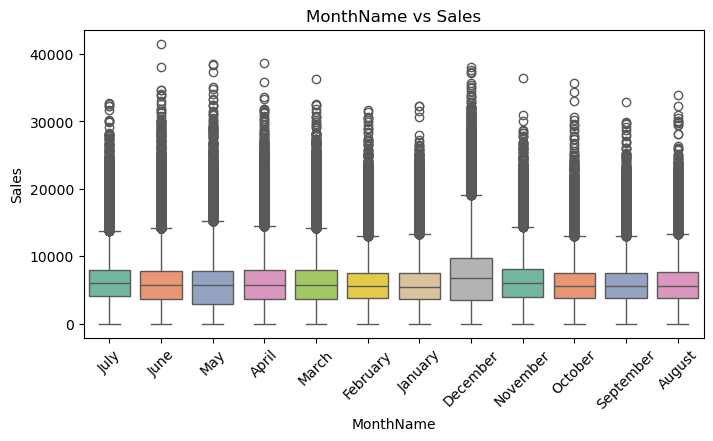

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\1029565144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_eda[col],y=df_eda["Sales"],palette="Set2")


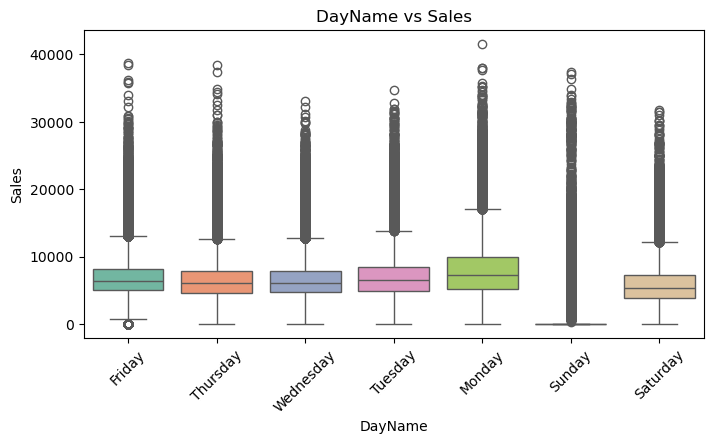

In [39]:
for col in catColumns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df_eda[col],y=df_eda["Sales"],palette="Set2")
    plt.title(f"{col} vs Sales")
    plt.xlabel(col)
    plt.ylabel("Sales")
    plt.xticks(rotation=45)
    plt.show()
# Boxplots used to analyze impact of categorical variables on Sales

*Boxplots were used to analyze the impact of categorical variables on Sales.*
*Significant variation in sales was observed across different categories.*

### Multivariate analysis

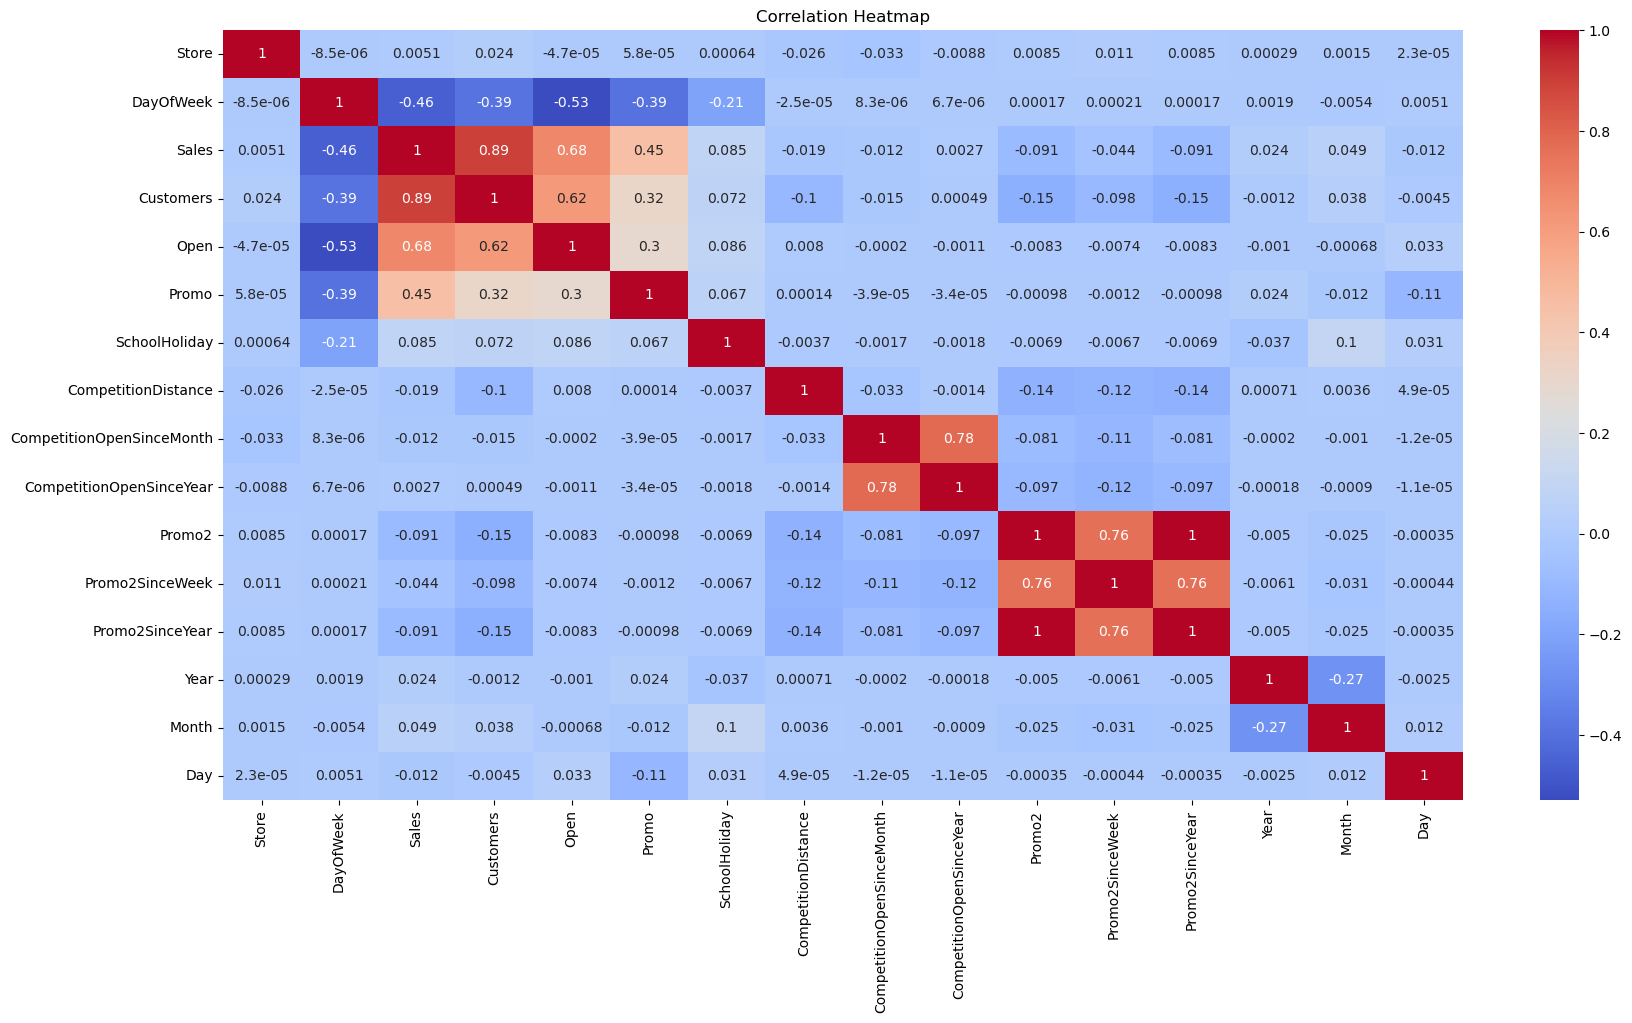

In [40]:
plt.figure(figsize=(20,10))
sns.heatmap(df_eda.select_dtypes(include=["number"]).corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
# Correlation heatmap was generated using only numeric variables to ensure accurate and meaningful analysis

### Feature engineering after EDA

In [41]:
# Convert date column into datetime format
# df["Date"]=pd.to_datetime(df["Date"])

# Feature engineering after EDA
df["IsWeekend"]=df["DayName"].isin(["Saturday","Sunday"])

# Create month boundary features
df["IsMonthStart"]=df["Date"].dt.is_month_start
df["IsMonthEnd"]=df["Date"].dt.is_month_end

# Additional features such as weekend indicator and month boundaries were created after EDA to capture temporal patterns and improve model performance

### Drop columns

In [42]:
df.drop(["Store","Date"],axis=1,inplace=True)
# Unnecessary columns such as store(identifier) and Date were removed after feature extraction

### One-hot encoding

In [43]:
fullDf=pd.get_dummies(df,drop_first=True)
# Categorical variables were converted into numerical format using one-hot encoding

In [44]:
fullDf.shape

(1017209, 47)

In [45]:
fullDf.columns

Index(['DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo', 'SchoolHoliday',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'Year', 'Month', 'Day', 'IsWeekend', 'IsMonthStart',
       'IsMonthEnd', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b',
       'StateHoliday_c', 'StoreType_b', 'StoreType_c', 'StoreType_d',
       'Assortment_b', 'Assortment_c', 'PromoInterval_Jan,Apr,Jul,Oct',
       'PromoInterval_Mar,Jun,Sept,Dec', 'PromoInterval_None',
       'MonthName_August', 'MonthName_December', 'MonthName_February',
       'MonthName_January', 'MonthName_July', 'MonthName_June',
       'MonthName_March', 'MonthName_May', 'MonthName_November',
       'MonthName_October', 'MonthName_September', 'DayName_Monday',
       'DayName_Saturday', 'DayName_Sunday', 'DayName_Thursday',
       'DayName_Tuesday', 'DayName_Wednesday'],
      dtype='object')

### Train_Test_Split

**Divide the dataset**

In [46]:
from sklearn.model_selection import train_test_split

trainDf,testDf=train_test_split(fullDf,test_size=0.2,random_state=2410)
print(trainDf.shape,testDf.shape)

(813767, 47) (203442, 47)


### Separate variables and target

**Dependent & independent variables**

In [47]:
trainX=trainDf.drop("Sales",axis=1)
trainY=trainDf["Sales"]
testX=testDf.drop("Sales",axis=1)
testY=testDf["Sales"]
print(trainX.shape,trainY.shape,testX.shape,testY.shape)
# The dataset was split into training and testing sets in an 80:20 ratio

(813767, 46) (813767,) (203442, 46) (203442,)


### Feature scaling

In [48]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler().fit(trainX)

# Transform training data
trainSd=scaler.transform(trainX)
# Transform test data
testSd=scaler.transform(testX)
# When we standardize our dataframe it changes into the array form

trainStd=pd.DataFrame(trainSd,columns=trainX.columns)
testStd=pd.DataFrame(testSd,columns=testX.columns)
# Feature scaling was applied using StandardScaler to normalize the data

### Model building

**Pipeline model**

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

pipeline=Pipeline([("model",RandomForestRegressor(n_estimators=50,n_jobs=-1,random_state=2410))]).fit(trainStd,trainY)
# A pipeline was implemented to streamline the modeling process and ensure reproducibility

### Prediction

In [50]:
y_pred=pipeline.predict(testStd)
# Predictions were generated using the trained model on test data

In [51]:
testY[0:5]

837246    6240
233550    4347
75648        0
344591       0
650056    2825
Name: Sales, dtype: int64

In [52]:
y_pred[0:5]

array([6128.02, 4500.34,    0.  ,    0.  , 2840.54])

### Model evaluation

In [53]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
print("MSE:",mean_squared_error(testY,y_pred))
print("MAE:",mean_absolute_error(testY,y_pred))
print("R2 Score:",r2_score(testY,y_pred))
# The model was evaluated using mean_squared_error,mean_absolute_error and r2_score

MSE: 210136.37541130715
MAE: 273.91147225557677
R2 Score: 0.98578443171933


### Feature importance

In [54]:
# Get importance from random forest inside pipeline
importance=pipeline.named_steps["model"].feature_importances_
# Convert into series
varImportance=pd.Series(importance,index=trainX.columns)

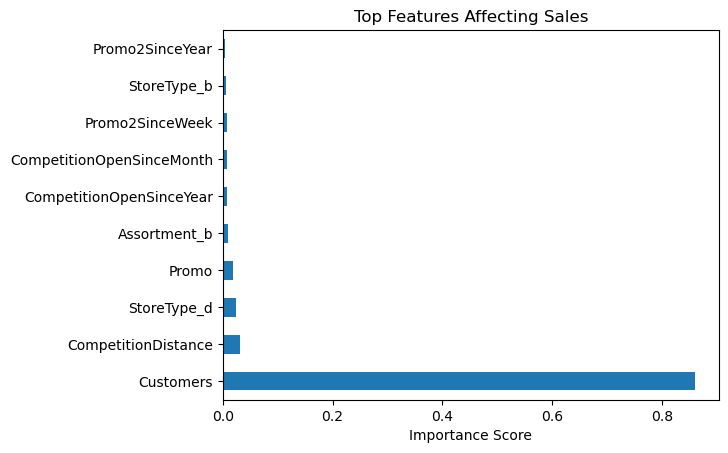

In [55]:
# Top 10 features
varImportance.nlargest(10).plot(kind="barh") # "barh"->left/right(horizontal)
plt.title("Top Features Affecting Sales")
plt.xlabel("Importance Score")
plt.show()

*Feature importance analysis was conducted to identify key factors affecting sales.*

### Serialization

In [56]:
import pickle
pickle.dump(pipeline,open("model.pkl","wb")) # "wb"->Write in binary mode
# The trained model was saved using pickle for future use and deployment

### Test data preprocessing

**Merge test dataset**

In [57]:
#  Merge test dataset
testDf=pd.read_csv(r"C:\Users\ajayk\OneDrive\Desktop\Digicrome_E-Learning\Nexthikes Internship Project Training\Project_06\test.csv")
testDf=pd.merge(testDf,storeDf,on="Store",how="left")

**Dimensions**

In [58]:
testDf.shape
# It will display the total number of rows and columns.We've 41088 rows and 17 columns

(41088, 17)

In [59]:
print("Total number of rows:",testDf.shape[0])
print("Total number of columns:",testDf.shape[1])

Total number of rows: 41088
Total number of columns: 17


**Information**

In [60]:
# Column types and not null counts
testDf.info()
# It will give us the complete info of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Id                         41088 non-null  int64  
 1   Store                      41088 non-null  int64  
 2   DayOfWeek                  41088 non-null  int64  
 3   Date                       41088 non-null  object 
 4   Open                       41077 non-null  float64
 5   Promo                      41088 non-null  int64  
 6   StateHoliday               41088 non-null  object 
 7   SchoolHoliday              41088 non-null  int64  
 8   StoreType                  41088 non-null  object 
 9   Assortment                 41088 non-null  object 
 10  CompetitionDistance        40992 non-null  float64
 11  CompetitionOpenSinceMonth  25872 non-null  float64
 12  CompetitionOpenSinceYear   25872 non-null  float64
 13  Promo2                     41088 non-null  int

**Describe**

In [61]:
# Statistical summary
testDf.describe()
# It will give us the statistical info of the complete dataframe

,Id,Store,DayOfWeek,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,41088.000000,41088.000000,41088.000000,41077.000000,41088.000000,41088.000000,40992.000000,25872.000000,25872.000000,41088.000000,23856.000000,23856.000000
mean,20544.500000,555.899533,3.979167,0.854322,0.395833,0.443487,5088.583138,7.035250,2008.641929,0.580607,24.426559,2011.820926
std,11861.228267,320.274496,2.015481,0.352787,0.489035,0.496802,7225.487467,3.143015,6.862400,0.493466,14.161312,1.692166
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,10272.750000,279.750000,2.000000,1.000000,0.000000,0.000000,720.000000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,20544.500000,553.500000,4.000000,1.000000,0.000000,0.000000,2425.000000,7.000000,2010.000000,1.000000,22.000000,2012.000000
75%,30816.250000,832.250000,6.000000,1.000000,1.000000,1.000000,6480.000000,9.000000,2012.000000,1.000000,37.000000,2013.000000
max,41088.000000,1115.000000,7.000000,1.000000,1.000000,1.000000,75860.000000,12.000000,2015.000000,1.000000,49.000000,2015.000000


**Head**

In [62]:
testDf.head()
# # By default it displays first five rows and it will always display from the starting only

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN


**Tail**

In [63]:
testDf.tail()
# By default it displays last five rows and it will always display from the ending only

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
41083,41084,1111,6,2015-08-01,1.0,0,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
41084,41085,1112,6,2015-08-01,1.0,0,0,0,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
41085,41086,1113,6,2015-08-01,1.0,0,0,0,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
41086,41087,1114,6,2015-08-01,1.0,0,0,0,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN
41087,41088,1115,6,2015-08-01,1.0,0,0,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"


**Sample**

In [64]:
testDf.sample()
# It displays random rows and by default it display one random row

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
39343,39344,1072,1,2015-08-03,1.0,1,0,1,a,c,5380.0,8.0,2015.0,1,5.0,2010.0,"Feb,May,Aug,Nov"


**Columns**

In [65]:
testDf.columns
# It will display the column names

Index(['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

**Check duplicates and drop duplicates**

In [66]:
# To find the duplicate rows=>duplicated()
print("Total Number of Duplicates:",testDf.duplicated().sum())
# There are no duplicate rows. So we don't need to identify and drop columns

Total Number of Duplicates: 0


**Handle missing values**

In [67]:
testDf.isna().sum() # It displays column wise count of missing values
# There are 11 missing values in "Open" 
# 96 missing values in "CompetitionDistance"
# 15216 missing values in "CompetitionOpenSinceMonth"
# 15216 missing values in "CompetitionOpenSinceYear"
# 17232 missing values in "Promo2SinceWeek"
# 17232 missing values in "Promo2SinceYear"
# 17232 missing values in "PromoInterval"

# All missing values in the dataset were handled appropriately using statistical methods
# and domain knowledge to ensure data consistency and improve model performance

Id                               0
Store                            0
DayOfWeek                        0
Date                             0
Open                            11
Promo                            0
StateHoliday                     0
SchoolHoliday                    0
StoreType                        0
Assortment                       0
CompetitionDistance             96
CompetitionOpenSinceMonth    15216
CompetitionOpenSinceYear     15216
Promo2                           0
Promo2SinceWeek              17232
Promo2SinceYear              17232
PromoInterval                17232
dtype: int64

**Check data type**

In [68]:
# Check the data type
print(testDf["Open"].dtypes)
print(testDf["CompetitionDistance"].dtypes)
print(testDf["CompetitionOpenSinceMonth"].dtypes)
print(testDf["CompetitionOpenSinceYear"].dtypes)
print(testDf["Promo2SinceWeek"].dtypes)
print(testDf["Promo2SinceYear"].dtypes)
print(testDf["PromoInterval"].dtypes)

float64
float64
float64
float64
float64
float64
object


- Open

In [69]:
tempOpen=1
testDf["Open"].fillna(tempOpen,inplace=True)
# Missing values in "Open" were filled 1 assuming the store was open

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\3830084931.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  testDf["Open"].fillna(tempOpen,inplace=True)


- CompetitionDistance

In [70]:
tempMedian=testDf["CompetitionDistance"].median()
testDf["CompetitionDistance"].fillna(tempMedian,inplace=True)
# Missing values in "CompetitionDistance" were filled using the median to reduce the impact of outliers

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\2176296562.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  testDf["CompetitionDistance"].fillna(tempMedian,inplace=True)


- CompetitionOpenSinceMonth
- CompetitionOpenSinceYear

In [71]:
tempCompMonth=0
tempCompYear=0
testDf["CompetitionOpenSinceMonth"].fillna(tempCompMonth,inplace=True)
testDf["CompetitionOpenSinceYear"].fillna(tempCompYear,inplace=True)
# Missing values in competition start features were replaced with 0 including absence of competition

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\3076550023.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  testDf["CompetitionOpenSinceMonth"].fillna(tempCompMonth,inplace=True)
C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\3076550023.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

- Promo2SinceWeek
- Promo2SinceYear

In [72]:
tempPromoWeek=0
tempPromoYear=0
testDf["Promo2SinceWeek"].fillna(tempPromoWeek,inplace=True)
testDf["Promo2SinceYear"].fillna(tempPromoYear,inplace=True)
# Missing values in promo start features were replaced with 0 indicating no active promotion 

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\2176590257.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  testDf["Promo2SinceWeek"].fillna(tempPromoWeek,inplace=True)
C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\2176590257.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

- PromoInterval(Categorical)

In [73]:
tempPromoInterval="None"
testDf["PromoInterval"].fillna(tempPromoInterval,inplace=True)
# Missing values in "PromoInterval" were replaced with "None" indicating no promotional activity

C:\Users\ajayk\AppData\Local\Temp\ipykernel_17768\724816731.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  testDf["PromoInterval"].fillna(tempPromoInterval,inplace=True)


**Check the missing values**

In [74]:
# Check missing values
testDf.isna().sum()

Id                           0
Store                        0
DayOfWeek                    0
Date                         0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

**Feature Engineering**

In [75]:
testDf["Date"]=pd.to_datetime(testDf["Date"])

testDf["Year"]=testDf["Date"].dt.year
testDf["Month"]=testDf["Date"].dt.month
testDf["Day"]=testDf["Date"].dt.day
testDf["DayOfWeek"]=testDf["Date"].dt.day_of_week

testDf["IsWeekend"]=testDf["DayOfWeek"].isin([5,6])
testDf["IsMonthStart"]=testDf["Date"].dt.is_month_start
testDf["IsMonthEnd"]=testDf["Date"].dt.is_month_end

# Data-based features were extracted to capture temporal patterns affecting sales

In [76]:
# It checks whether the day of the week corresponds to Saturday and Sunday

**Drop unnecessary columns**

In [77]:
testDf.drop(["Store","Date"],axis=1,inplace=True)
# The "Store" column was removed as it is an indentifier,and "Date" was dropped after extracting useful features

**One-hot encoding**

In [78]:
testDf=pd.get_dummies(testDf,drop_first=True)
# Categorical variables were converted into numerical format using one-hot encoding

**Align with train data**

In [79]:
testDf=testDf.reindex(columns=trainX.columns,fill_value=0) # Adds missing columns,Removes extra columns,Keeps same order
# The test dataset was aligned with the training dataset to ensure consistent feature structure

**Scaling**

**Prediction**

In [80]:
testPred=pipeline.predict(testDf)
# Prediction were generated using the trained machine learning model

**Save output**

In [81]:
submission=pd.DataFrame({"Id":pd.read_csv(r"C:\Users\ajayk\OneDrive\Desktop\Digicrome_E-Learning\Nexthikes Internship Project Training\Project_06\test.csv")
                         ["Id"],"Sales":testPred})
submission.to_csv("submission.csv",index=False)
# The predict results were saved into a CSV file for submission

### LSTM preparation

In [82]:
from sklearn.preprocessing import MinMaxScaler
scaler_lstm=MinMaxScaler(feature_range=(-1,1))
scaled=scaler_lstm.fit_transform(df[["Sales"]])

X_lstm,y_lstm=[],[]

for i in range(60,len(scaled)):
    X_lstm.append(scaled[i-60:i])
    y_lstm.append(scaled[i])
X_lstm,y_lstm=np.array(X_lstm),np.array(y_lstm)

In [83]:
print(X_lstm.shape)
print(y_lstm.shape)

(1017149, 60, 1)
(1017149, 1)


### Train_Test_Split

In [84]:
split=int(0.8*len(X_lstm))
X_train,X_test=X_lstm[:split],X_lstm[split:]
y_train,y_test=y_lstm[:split],y_lstm[split:]
# Splitting data into 80% training and 20% testing

### Build lstm model

In [85]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense
# Building stacked LSTM model
model=Sequential([LSTM(50,return_sequences=True,input_shape=(X_lstm.shape[1],1)),LSTM(50),Dense(1)]) 
# 50 units->neurons
# return_sequences=True->passes sequence to next LSTM(Long Short-Term Memory)
# input_shape->timesteps,features
# LSTM(50)->processes sequence->outputs final value
# Dense(1)->final output->predicted sales value

C:\Users\ajayk\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Compile model

In [86]:
model.compile(optimizer="adam",loss="mse",metrics=["mae"]) # Compile the model using adam optimizer and mse loss
# optimizer="adam"->Adaptive optimizer(It adjusts weights intelligently during training
# loss="mse"->square of (Actual-Predicted)
# metrics=["mae"]->mean absolute error(evaluation)

### Train model

In [87]:
model.fit(X_train,y_train,epochs=5,batch_size=32)
# Training the model on training data

Epoch 1/5
25429/25429 ━━━━━━━━━━━━━━━━━━━━ 1849s 72ms/step - loss: 0.0165 - mae: 0.0875
Epoch 2/5
25429/25429 ━━━━━━━━━━━━━━━━━━━━ 2122s 83ms/step - loss: 0.0155 - mae: 0.0835
Epoch 3/5
10827/25429 ━━━━━━━━━━━━━━━━━━━━ 19:39 81ms/step - loss: 0.0146 - mae: 0.0812

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



25429/25429 ━━━━━━━━━━━━━━━━━━━━ 1823s 72ms/step - loss: 0.0139 - mae: 0.0795
Epoch 4/5
25429/25429 ━━━━━━━━━━━━━━━━━━━━ 790s 31ms/step - loss: 0.0110 - mae: 0.0707 
Epoch 5/5
25429/25429 ━━━━━━━━━━━━━━━━━━━━ 801s 32ms/step - loss: 0.0088 - mae: 0.0626 


### Prediction

In [88]:
modelPred=model.predict(X_test)
# Generating predictions on test data

6358/6358 ━━━━━━━━━━━━━━━━━━━━ 77s 12ms/step 


### Inverse scaling

In [89]:
# Converting scaled predictions back to original sales values
predicted_actual=scaler_lstm.inverse_transform(modelPred)
# Converting actual test values back
y_test_actual=scaler_lstm.inverse_transform(y_test)

### Visualization

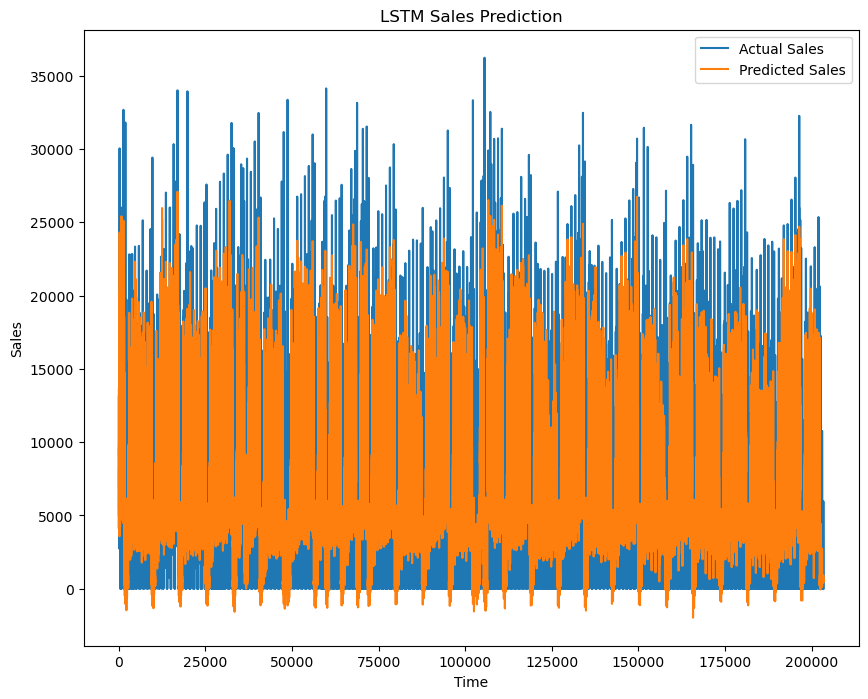

In [90]:
# Plotting actual vs predicted sales
plt.figure(figsize=(10,8))
plt.plot(y_test_actual,label="Actual Sales")
plt.plot(predicted_actual,label="Predicted Sales")
plt.title("LSTM Sales Prediction")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.show()

### Evaluation

In [91]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test_actual,predicted_actual)
mae=mean_absolute_error(y_test_actual,predicted_actual)
r2Score=r2_score(y_test_actual,predicted_actual)
print("MSE:",mse)
print("MAE:",mae)
print("R2 Score:",r2Score)
# The model performance was evaluated using MSE,MAE, and r2_score metrics

MSE: 3479993.3682615003
MAE: 1293.5366426454775
R2 Score: 0.7507622787457235


### Create final output

In [93]:
# Flatten predictions
lstm_predictions=predicted_actual.flatten()
# Create submission dataframe
submission=pd.DataFrame({"Id":range(len(lstm_predictions)),"Sales":lstm_predictions})
# Save to CSV correctly
submission.to_csv("lstm_submission.csv",index=False)

### Visualization

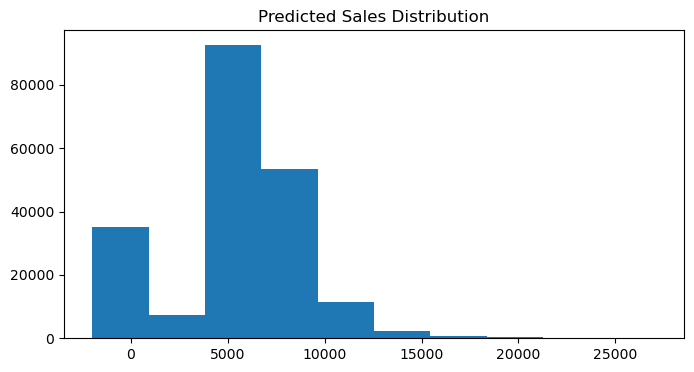

In [94]:
plt.figure(figsize=(8,4))
plt.hist(predicted_actual)
plt.title("Predicted Sales Distribution")
plt.show()

### Create streamlit app

In [95]:
pip install streamlit

In [99]:
import streamlit as st
import pickle
import pandas as pd
# Load model
model=pickle.load(open("model.pkl","rb"))

st.title("Rossmann Sales Prediction")

# User inputs
store=st.number_input("Store ID",min_value=1)
promo=st.selectbox("Promo",[0,1])
holiday=st.selectbox("Holiday",[0,1])
day=st.number_input("Day",1,31)
month=st.number_input("Month",1,12)
year=st.number_input("Year",2013,2015)

# Create input dataframe
inputDf=pd.DataFrame({"Store":[store],"Promo":[promo],"Holiday":[holiday],"Day":[day],"Month":[month],"Year":[year]})

# Prediction
if st.button("Predict Sales"): # It creates a button in streamlit app
    prediction=model.predict(inputDf)
    st.success(f"Predicted Sales:{prediction[0].item():.2f}") # item()->converts numpy value to normal python number,.2f->2 decimal places

2026-06-16 14:03:43.232 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 14:03:43.288 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 14:03:43.314 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 14:03:43.323 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 14:03:43.331 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 14:03:43.343 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 14:03:43.366 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 14:03:43.369 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar